#### 손가락 숫자 모양의 Image 분류

In [1]:
import warnings
warnings.filterwarnings("ignore")

----
#### Data 불러오기

In [2]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
train_images = glob.glob('../data/fingers/fingers/train/*.png') # 데이터가 아니라, file name을 가지고 옴
test_images = glob.glob('../data/fingers/fingers/test/*.png')

In [4]:
# train_images = glob.glob('../Data/fingers/train/*.png')
# test_images = glob.glob('../Data/fingers/test/*.png')

In [5]:
# 잘 가지고 왔는지 확인
# file name 확인
train_images[:5] # file name이 잘 가지고 왔는지 확인

['../data/fingers/fingers/train/9e3cb712-4679-4e23-bc0f-fc0606e0ca58_5R.png',
 '../data/fingers/fingers/train/93486912-fc61-40f3-bd74-fca8d77fb52f_4R.png',
 '../data/fingers/fingers/train/4490a85e-2a7b-457e-a1ff-c2504980c17a_2L.png',
 '../data/fingers/fingers/train/9e158656-ce8c-471d-9fb4-d342ff6e0d78_3L.png',
 '../data/fingers/fingers/train/5f38e471-44be-442c-879d-f5d0d733821c_3R.png']

In [6]:
# 갯수 확인
print(len(train_images))
print(len(test_images))

18000
3600


In [ ]:
# train data와 test data만들기 : 128 * 128 -> 32 * 32 로 변경
X_train = []
X_test = []
y_train = []
y_test = []

# train data
for image in sorted(train_images):
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS) # 이미지 사이즈 변경 , Resampling.LANCZOS : 고품질의 리샘플링 방법(깨지지 않게 만드는 거 )
    X_train.append(imgResize) # 이미지 데이터를 리스트에 추가 _input
    y_train.append(image[-6:-4]) # target _ 두글자만 따와서 넣음

# test data
for image in sorted(test_images):
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS) # 이미지 사이즈 변경 , Resampling.LANCZOS : 고품질의 리샘플링 방법(깨지지 않게 만드는 거 )
    X_test.append(imgResize) # 이미지 데이터를 리스트에 추가
    y_test.append(image[-6:-4])

In [8]:
# label Data 확인 | y_test.append(image[-6:-4]) 이거 잘 됐는지 확인, 앞에껀 아직 그림이라서

print(y_train[:5])
print(y_test[:5])


['0L', '0L', '2L', '0L', '5L']
['5L', '5L', '3R', '5L', '5L']


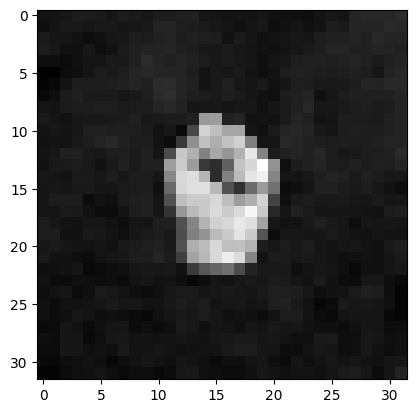

In [9]:
# train의 이미지 확인 
plt.imshow(X_train[0], cmap='gray')
plt.show()

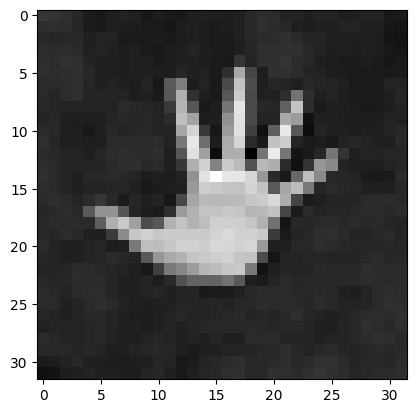

In [10]:
# test의 이미지 확인
plt.imshow(X_test[0],cmap='gray')
plt.show()

---
#### numpy 배열로 변경

In [11]:
import numpy as np

In [ ]:
# train data 만들기
tempData = np.zeros(# 3차원 데이터로 바꿔줌
                18000 * 32 * 32, # 이미지의 총 픽셀 수 (18000장 * 32픽셀 * 32픽셀
                dtype=np.int32
).reshape(18000, 32, 32) # 18000장의 이미지를 32x32 픽셀로 변환

i = 0
for image in X_train:
    img = np.array(image, dtype=np.int32)
    tempData[i,:,:] = img # 0에 이미지 하나 들어가는데, 나머지는 너가 알아서 하라고 정해줌
    i+=1

X_train = tempData.copy()

In [13]:
# test data 만들기
tempData = np.zeros(
                3600 * 32 * 32, 
                dtype=np.int32
).reshape(3600, 32, 32)

i = 0
for image in X_test:
    img = np.array(image, dtype=np.int32)
    tempData[i,:,:] = img
    i+=1

X_test = tempData.copy()

In [14]:
tempData.shape

(3600, 32, 32)

In [15]:
# 배열 크기 확인
print(X_train.shape, X_test.shape)

(18000, 32, 32) (3600, 32, 32)


In [16]:
y_train[:5]

['0L', '0L', '2L', '0L', '5L']

---
#### Label을 one hot encoding으로 변경하기

In [17]:
label_to_int = {
    '0R' : 0,
    '1R' : 1,
    '2R' : 2,
    '3R' : 3,
    '4R' : 4,
    '5R' : 5,
    '0L' : 6,
    '1L' : 7,
    '2L' : 8,
    '3L' : 9,
    '4L' : 10,
    '5L' : 11,
}

In [18]:
# 숫자로 변경하기
temp = []
for label in y_train:
    temp.append(label_to_int[label])
y_train = temp.copy()

temp = []
for label in y_test:
    temp.append(label_to_int[label])
y_test = temp.copy()

In [36]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [37]:
y_train[:5]

array([ 6,  6,  8,  6, 11])

----
#### Train, Valid 정규화 하기

In [21]:
train_data  = X_train / 255 # _ 정규화 해주려고 
test_data  = X_test / 255 # _ 정규화 해주려고

In [22]:
# train -> train, vaild 분리
from sklearn.model_selection import train_test_split

# train_scaled = train_scaled.reshape(-1, 28 * 28) #  이건 했으니까 안해도 되고

train_scaled, val_scaled, train_target, val_target = train_test_split(
                                                        train_data,
                                                        y_train, 
                                                        test_size=0.2, 
                                                        random_state=42
)

In [23]:
train_scaled.shape

(14400, 32, 32)

----
#### Deep Learning Model 만들기 

In [ ]:
from tensorflow import keras
from tensorflow.keras.layers import Input
# 입력층 : 1024
# 은닉층 : 32
# 출력층 : 11
# activation : signoid, tanh ,relu,leakyRelu


# model = keras.Sequential()
# model.add(Input(shape=(784,)))
# model.add(keras.layers.Dense(1284,activation='relu')) # 은닉층 : 2의 배수
# model.add(keras.layers.Dense(10,activation='softmax'))


# model = keras.Sequential()
# model.add(keras.layers.Flatten(input_shape=(32, 32)))
# model.add(keras.layers.Dense(128, activation='relu')) 
# model.add(keras.layers.Dense(12, activation='softmax'))


model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(32, 32))) # 들어올게  32*32로 들어올 거야
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(12, activation='softmax'))



---
#### Train, Vaild, Test 정확도 비교

In [25]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 훈련 시키기 
# ㄸ
# hist = model.fit(
#         train_data,
#         test_data,
#         epochs=50,
#         validation_data=(test_data, y_test)
# )
hist = model.fit(
        train_data,
        y_train, # 지금에선 x가 input, y가 target
        epochs=5,
        validation_data=(val_scaled, val_target)
)



Epoch 1/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9988 - loss: 0.0128 - val_accuracy: 0.9992 - val_loss: 0.0089
Epoch 2/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9986 - loss: 0.0101 - val_accuracy: 0.9996 - val_loss: 0.0072
Epoch 3/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9988 - loss: 0.0081 - val_accuracy: 0.9979 - val_loss: 0.0143
Epoch 4/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9994 - loss: 0.0049 - val_accuracy: 0.9993 - val_loss: 0.0074
Epoch 5/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9989 - loss: 0.0054 - val_accuracy: 1.0000 - val_loss: 0.0021


In [33]:
model.evaluate(np.array(train_scaled),np.array(train_target))

450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 906us/step - accuracy: 1.0000 - loss: 0.0021


[0.002066019456833601, 1.0]

In [34]:
model.evaluate(np.array(val_scaled),np.array(val_target))

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step - accuracy: 1.0000 - loss: 0.0024


[0.0023739503230899572, 1.0]

In [40]:
model.evaluate(X_test,y_test)

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - accuracy: 1.0000 - loss: 0.0000e+00


[0.0, 1.0]

---
#### 해당 모델을 pic.png로 확인해보기

In [42]:
test_img = Image.open("../Data/pic.png")
test_imgResize = test_img.resize((32, 32), Image.Resampling.LANCZOS) # 이미지 사이즈 변경 , Resampling.LANCZOS : 고품질의 리샘플링 방법(깨지지 않게 만드는 거 )

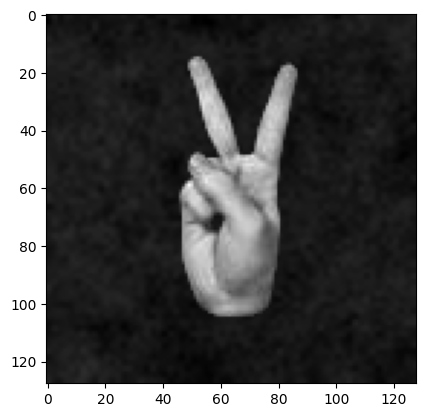

In [43]:
# train의 이미지 확인 
plt.imshow(test_img, cmap='gray')
plt.show()

In [46]:
test_img[:5]

array([[39, 44, 53, 53, 43, 41, 50, 53, 52, 48, 44, 44, 48, 48, 46, 44,
        42, 43, 45, 47, 48, 50, 50, 49, 48, 49, 53, 52, 46, 44, 46, 49,
        53, 51, 44, 39, 37, 39, 47, 50, 50, 49, 48, 48, 46, 45, 46, 47,
        47, 44, 36, 32, 34, 35, 34, 36, 39, 41, 43, 44, 45, 43, 39, 40,
        47, 47, 40, 39, 46, 48, 46, 45, 44, 45, 46, 46, 45, 44, 44, 43,
        41, 40, 38, 38, 39, 40, 41, 44, 50, 51, 48, 49, 52, 55, 57, 56,
        49, 45, 44, 40, 34, 37, 49, 53, 50, 49, 50, 55, 62, 63, 59, 56,
        56, 56, 54, 53, 53, 52, 50, 50, 51, 51, 51, 52, 52, 54, 57, 59],
       [37, 42, 51, 52, 43, 42, 49, 52, 50, 47, 44, 44, 47, 47, 45, 44,
        44, 44, 45, 46, 47, 48, 48, 48, 47, 48, 51, 50, 47, 45, 46, 48,
        50, 49, 46, 42, 40, 41, 46, 47, 46, 46, 48, 48, 47, 46, 45, 45,
        46, 42, 35, 32, 33, 34, 33, 33, 36, 38, 40, 42, 44, 43, 39, 40,
        45, 45, 40, 41, 47, 48, 46, 44, 43, 43, 45, 45, 45, 44, 44, 43,
        43, 41, 40, 40, 41, 42, 43, 45, 50, 51, 49, 50, 53, 55,

In [48]:
test_img = np.array(test_img, dtype=np.int32)


In [51]:
test_img.shape


(32, 32)

In [50]:
from PIL import Image
import numpy as np

# test_img가 현재 numpy 배열이고 shape가 (128, 128)일 때
test_img = Image.fromarray(test_img)
test_img = test_img.resize((32, 32), Image.Resampling.LANCZOS)

test_img = np.array(test_img, dtype=np.int32)


In [ ]:
test_img = test_img / 255.0
test_img = test_img.reshape(1, 32, 32) # 차원을 바꿔준 거_ 이미지 1개 , 우리가 resize 해준 값을 넣은 거 

pred = model.predict(test_img)
pred_num = np.argmax(pred) # 시퀀스의 최댓값출력

print(pred_num)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
2


In [53]:
# image를 numpy 배열로 바꿔주기
imgArray = np.array(test_img)
imgArray = imgArray / 255
imgArray.shape

(1, 32, 32)

In [54]:
# imgArray를 1차원 배열로 변경하기
imgArray2 = imgArray.reshape(-1) # _ -1 : 자동으로 계산해서 넣어줌 / -1을 넣은 이유 :
imgArray2.shape

(1024,)

In [55]:
import pandas as pd

In [56]:
imgArray3 = imgArray2.tolist()
dfArray = pd.DataFrame(imgArray3)
dfArray = dfArray.T
dfArray

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0.000661,0.000723,0.000707,0.000692,0.000707,0.000707,0.000738,0.000738,0.000707,0.000661,...,0.000692,0.000631,0.000769,0.00083,0.00083,0.000754,0.000615,0.000646,0.000692,0.000677


In [59]:
type(dfArray)


pandas.DataFrame

In [60]:
np.array(dfArray).shape


(1, 1024)

In [62]:
from PIL import Image
import numpy as np

test_img = Image.open("../Data/pic.png").convert("L")
test_img = test_img.resize((32, 32), Image.Resampling.LANCZOS)

dfArray = np.array(test_img, dtype=np.float32)
dfArray = dfArray / 255.0
dfArray = dfArray.reshape(1, 32, 32)

pred = model.predict(dfArray)
pred_num = np.argmax(pred)

print(pred_num)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2


In [ ]:
np.argmax(model.predict(dfArray)) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


np.int64(2)